In [1]:
# ============================================================
# STEP 1: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# STEP 2: Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# ============================================================
# STEP 3: Load Dataset
# ============================================================
df = pd.read_csv("/content/drive/MyDrive/medical_insurance.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Shape: (100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,48299,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,...,0,0,1,1,0,1,0,1,1,1
1,81048,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,...,0,0,0,0,0,0,1,0,0,0
2,92755,55,Male,East,Urban,226200.0,HS,Married,Employed,3,...,0,0,0,0,0,1,0,0,1,0
3,46008,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,...,0,1,0,1,0,0,1,0,0,0
4,76982,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,...,0,1,0,0,0,0,1,1,1,0


In [4]:
# ============================================================
# STEP 4: Feature Engineering (before split)
# ============================================================
df['age_x_bmi']       = df['age'] * df['bmi']
df['chronic_x_risk']  = df['chronic_count'] * df['risk_score']
df['hosp_x_days']     = df['hospitalizations_last_3yrs'] * df['days_hospitalized_last_3yrs']
df['proc_total']      = (df['proc_imaging_count'] + df['proc_surgery_count'] +
                         df['proc_physio_count']  + df['proc_consult_count'] +
                         df['proc_lab_count'])
df['med_visit_ratio'] = df['medication_count'] / (df['visits_last_year'] + 1)

In [5]:
# ============================================================
# STEP 5: Remove leakage columns, define X and y
# ============================================================
leakage_cols = ['annual_premium', 'monthly_premium',
                 'total_claims_paid', 'avg_claim_amount', 'claims_count']

X = df.drop(columns=['person_id', 'annual_medical_cost'] + leakage_cols)
y = df['annual_medical_cost']

print("Features shape:", X.shape)

Features shape: (100000, 52)


In [6]:
# ============================================================
# STEP 6: Log-transform the target
# ============================================================
y_log = np.log1p(y)

In [7]:
# ============================================================
# STEP 7: Train / Val / Test split (70 / 10 / 20)
# ============================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
X_temp_log, X_test_log, y_temp_log, y_test_log = train_test_split(
    X, y_log, test_size=0.20, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42)
X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(
    X_temp_log, y_temp_log, test_size=0.125, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (70000, 52) Val: (10000, 52) Test: (20000, 52)


In [8]:
# ============================================================
# STEP 8: Preprocessing pipeline
# ============================================================
numeric_features     = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object","category","bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [9]:
# ============================================================
# STEP 9: Hyperparameter tuning with LinearSVR (full data)
# ============================================================
C_values = [0.01, 0.1, 1, 10, 50, 100, 500]
cv_results = []

print("Tuning C with LinearSVR on full training data...\n")
for C in C_values:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("svr", LinearSVR(C=C, max_iter=5000, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train, y_train_log,
                              cv=5, scoring='r2', n_jobs=-1)
    cv_results.append({'C': C, 'mean_r2': scores.mean(), 'std_r2': scores.std()})
    print(f"  C={C:>6} | CV R²={scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('mean_r2', ascending=False)
best_C = cv_df.iloc[0]['C']
print(f"\nBest C selected: {best_C}")

Tuning C with LinearSVR on full training data...

  C=  0.01 | CV R²=0.2120 ± 0.0035
  C=   0.1 | CV R²=0.2120 ± 0.0036
  C=     1 | CV R²=0.2120 ± 0.0036
  C=    10 | CV R²=0.2073 ± 0.0040
  C=    50 | CV R²=0.0973 ± 0.0291
  C=   100 | CV R²=-0.0937 ± 0.0815
  C=   500 | CV R²=-0.5473 ± 0.1060

Best C selected: 0.01


In [10]:
# ============================================================
# STEP 10: Validate best LinearSVR on validation set
# ============================================================
val_model = Pipeline([
    ("preprocessor", preprocessor),
    ("svr", LinearSVR(C=best_C, max_iter=5000, random_state=42))
])
val_model.fit(X_train, y_train_log)

y_val_log_pred = val_model.predict(X_val)
y_val_pred     = np.expm1(y_val_log_pred)

val_mae  = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2   = r2_score(y_val, y_val_pred)

print(f"\nValidation Results (LinearSVR, C={best_C})")
print(f"  MAE : {val_mae:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  R²  : {val_r2:.4f}")


Validation Results (LinearSVR, C=0.01)
  MAE : 1642.9269
  RMSE: 2980.9839
  R²  : 0.1201


In [11]:
# ============================================================
# STEP 11: Final model — SVR(rbf) on 40k sample of Train+Val
# ============================================================
X_pool = pd.concat([X_train, X_val])
y_pool = pd.concat([y_train_log, y_val_log])

X_sample = X_pool.sample(n=40000, random_state=42)
y_sample = y_pool.loc[X_sample.index]

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("svr", SVR(kernel='rbf', C=best_C, epsilon=0.1, gamma='scale'))
])
best_model.fit(X_sample, y_sample)
print("\nFinal SVR(rbf) model trained.")


Final SVR(rbf) model trained.


In [12]:
# ============================================================
# STEP 12: Training metrics (on the 40k sample used)
# ============================================================
y_train_log_pred = best_model.predict(X_sample)
y_train_pred_orig = np.expm1(y_train_log_pred)
y_sample_orig     = np.expm1(y_sample)

train_mae  = mean_absolute_error(y_sample_orig, y_train_pred_orig)
train_rmse = np.sqrt(mean_squared_error(y_sample_orig, y_train_pred_orig))
train_r2   = r2_score(y_sample_orig, y_train_pred_orig)

print(f"\nTraining Results")
print(f"  MAE : {train_mae:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  R²  : {train_r2:.4f}")



Training Results
  MAE : 1665.8018
  RMSE: 2996.9442
  R²  : 0.0661


In [13]:
# ============================================================
# STEP 13: Final test evaluation
# ============================================================
y_test_log_pred = best_model.predict(X_test)
y_test_pred     = np.expm1(y_test_log_pred)

test_mae  = mean_absolute_error(y_test, y_test_pred)
test_mse  = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test, y_test_pred)

print(f"\nFinal Test Results")
print(f"  MAE : {test_mae:.4f}")
print(f"  MSE : {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²  : {test_r2:.4f}")


Final Test Results
  MAE : 1661.4581
  MSE : 9137244.2172
  RMSE: 3022.7875
  R²  : 0.0652


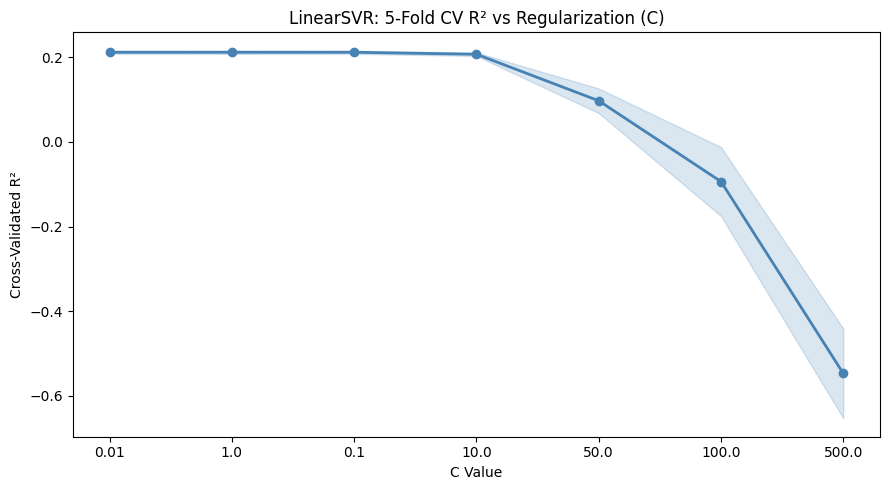

In [14]:
# ============================================================
# STEP 14: Visualization 1 — CV R² across C values
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(cv_df['C'].astype(str), cv_df['mean_r2'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(cv_df)),
                  cv_df['mean_r2'] - cv_df['std_r2'],
                  cv_df['mean_r2'] + cv_df['std_r2'],
                  alpha=0.2, color='steelblue')
plt.xlabel("C Value")
plt.ylabel("Cross-Validated R²")
plt.title("LinearSVR: 5-Fold CV R² vs Regularization (C)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/svr_v4/plot_cv_C_values.png", dpi=150)
plt.show()

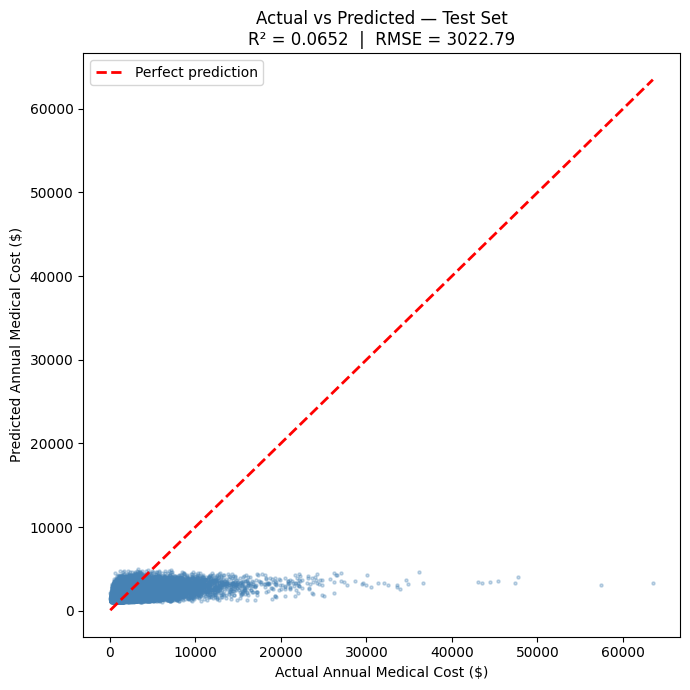

In [15]:
# ============================================================
# STEP 15: Visualization 2 — Actual vs Predicted (Test)
# ============================================================
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, alpha=0.3, s=5, color='steelblue')
mn = min(y_test.min(), y_test_pred.min())
mx = max(y_test.max(), y_test_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel("Actual Annual Medical Cost ($)")
plt.ylabel("Predicted Annual Medical Cost ($)")
plt.title(f"Actual vs Predicted — Test Set\nR² = {test_r2:.4f}  |  RMSE = {test_rmse:.2f}")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/svr_v4/plot_actual_vs_predicted.png", dpi=150)
plt.show()


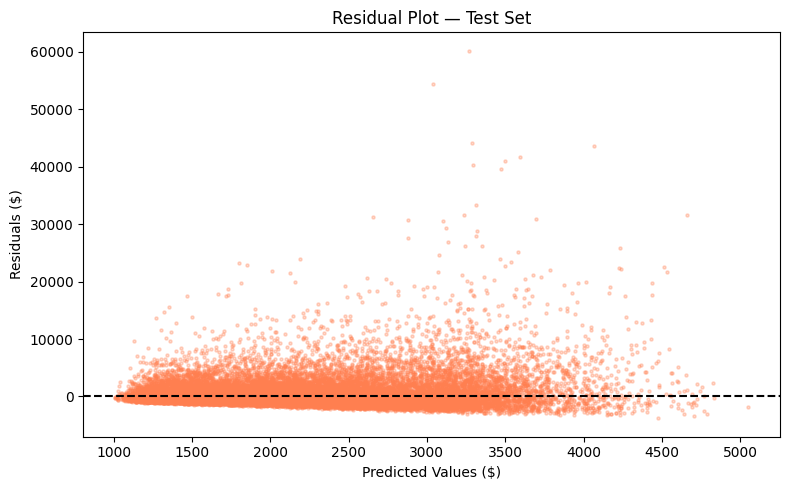

In [16]:
# ============================================================
# STEP 16: Visualization 3 — Residual plot
# ============================================================
residuals = y_test - y_test_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.3, s=5, color='coral')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values ($)")
plt.ylabel("Residuals ($)")
plt.title("Residual Plot — Test Set")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/svr_v4/plot_residuals.png", dpi=150)
plt.show()

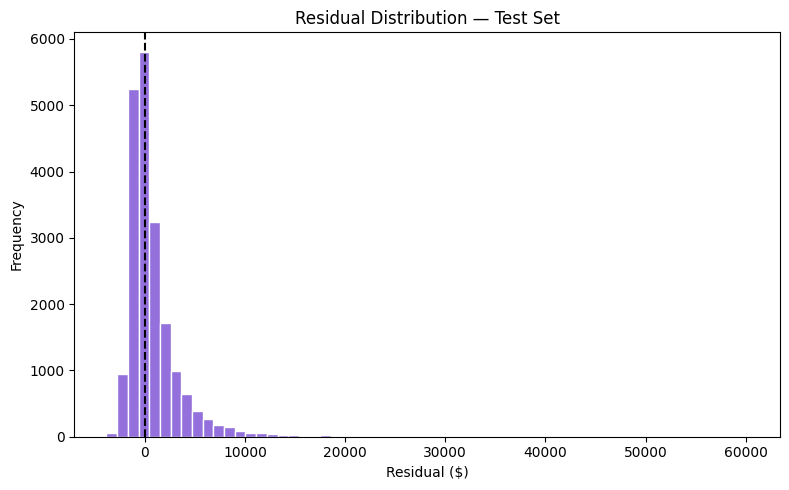

In [17]:
# ============================================================
# STEP 17: Visualization 4 — Residual distribution
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=60, color='mediumpurple', edgecolor='white')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Residual ($)")
plt.ylabel("Frequency")
plt.title("Residual Distribution — Test Set")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/svr_v4/plot_residual_dist.png", dpi=150)
plt.show()

<Figure size 1000x500 with 0 Axes>

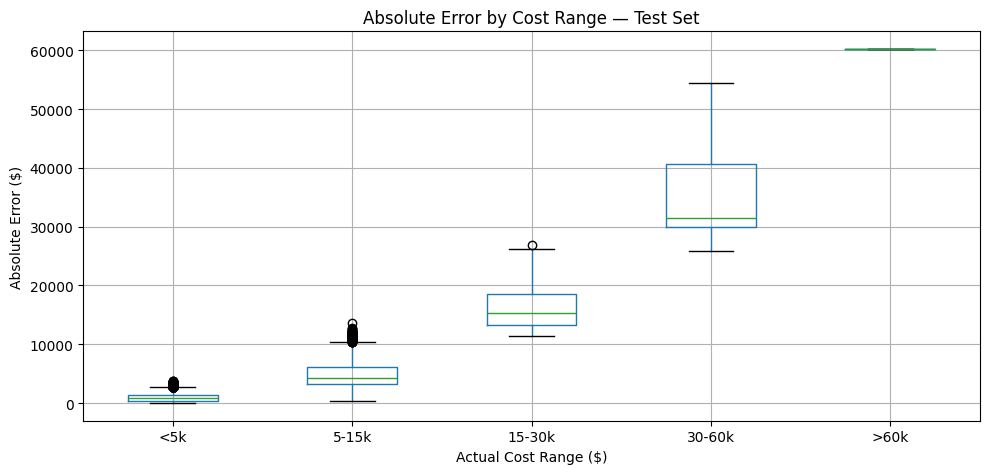

In [18]:
# ============================================================
# STEP 18: Visualization 5 — Error by cost range (box plot)
# ============================================================
y_test_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_test_pred})
y_test_df['abs_error'] = np.abs(y_test_df['actual'] - y_test_df['predicted'])
y_test_df['cost_bin'] = pd.cut(y_test_df['actual'],
                                 bins=[0, 5000, 15000, 30000, 60000, 200000],
                                 labels=['<5k','5-15k','15-30k','30-60k','>60k'])

plt.figure(figsize=(10, 5))
y_test_df.boxplot(column='abs_error', by='cost_bin', figsize=(10,5))
plt.suptitle('')
plt.title("Absolute Error by Cost Range — Test Set")
plt.xlabel("Actual Cost Range ($)")
plt.ylabel("Absolute Error ($)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/svr_v4/plot_error_by_range.png", dpi=150)
plt.show()

In [19]:
# ============================================================
# STEP 19: Save all results
# ============================================================
import os
os.makedirs("/content/drive/MyDrive/svr_v4", exist_ok=True)

cv_df.to_csv("/content/drive/MyDrive/svr_v4/svr_cv_results.csv", index=False)

pd.DataFrame([{
    'train_mae': train_mae, 'train_rmse': train_rmse, 'train_r2': train_r2,
    'val_mae':   val_mae,   'val_rmse':   val_rmse,   'val_r2':  val_r2,
    'test_mae':  test_mae,  'test_rmse':  test_rmse,  'test_r2': test_r2,
    'best_kernel': 'rbf', 'best_C': best_C, 'epsilon': 0.1, 'gamma': 'scale',
    'log_transform': True, 'leakage_removed': True,
    'feature_engineering': True, 'training_sample_size': 40000
}]).to_csv("/content/drive/MyDrive/svr_v4/svr_final_results.csv", index=False)

print("All results and plots saved to Google Drive.")

All results and plots saved to Google Drive.
